In [2]:
!unzip /content/sample_data/webbee-internship-2025.zip

Archive:  /content/sample_data/webbee-internship-2025.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('train.csv')

In [5]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15648047.0,Macleod,554.0,France,Female,32.0,3.0,98649.55,1.0,0.0,1.0,177099.71,0.0
1,1,15664681.0,Nnachetam,710.0,France,Male,38.0,9.0,0.00,2.0,0.0,0.0,141872.05,0.0
2,2,15762605.0,Zikoranachidimma,603.0,France,Female,38.0,9.0,136622.42,1.0,1.0,1.0,90212.38,0.0
3,3,15674750.0,Clements,710.0,France,Female,35.0,8.0,0.00,2.0,1.0,0.0,148811.81,0.0
4,4,15706463.0,Pinto,678.0,France,Male,34.0,8.0,0.00,2.0,0.0,0.0,148528.24,0.0


In [19]:
df.shape

(15000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


### Exploring Categorical Features

In [7]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts())
    print("-------------------------")


Value Counts for 'Surname':
Surname
Ch'iu        270
Ch'ien       250
Ch'ang       209
Hsia         207
T'ien        197
            ... 
Akubundu       1
Crawford       1
Sneddon        1
Douglas        1
MacDevitt      1
Name: count, Length: 767, dtype: int64
-------------------------

Value Counts for 'Geography':
Geography
France     8990
Spain      3350
Germany    2660
Name: count, dtype: int64
-------------------------

Value Counts for 'Gender':
Gender
Male      8477
Female    6523
Name: count, dtype: int64
-------------------------


In [10]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,7499.500000,1.570224e+07,658.001000,37.737400,5.077600,42918.259637,1.589933,0.778400,0.484867,1.177050e+05,0.200133
std,4330.271354,1.151398e+06,73.498209,8.153809,2.794083,59874.716430,0.530218,0.415337,0.499788,4.713009e+04,0.400113
min,0.000000,1.556570e+07,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.158000e+01,0.000000
25%,3749.750000,1.563537e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,8.305543e+04,0.000000
50%,7499.500000,1.569054e+07,660.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,1.235473e+05,0.000000
75%,11249.250000,1.575784e+07,709.000000,42.000000,7.000000,111064.280000,2.000000,1.000000,1.000000,1.564371e+05,0.000000
max,14999.000000,1.564367e+08,850.000000,74.000000,10.000000,205770.780000,4.000000,1.000000,1.000000,1.557651e+06,1.000000


In [11]:
df = df.drop(columns=['id', 'CustomerId', 'Surname'])
display(df.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,554.0,France,Female,32.0,3.0,98649.55,1.0,0.0,1.0,177099.71,0.0
1,710.0,France,Male,38.0,9.0,0.00,2.0,0.0,0.0,141872.05,0.0
2,603.0,France,Female,38.0,9.0,136622.42,1.0,1.0,1.0,90212.38,0.0
3,710.0,France,Female,35.0,8.0,0.00,2.0,1.0,0.0,148811.81,0.0
4,678.0,France,Male,34.0,8.0,0.00,2.0,0.0,0.0,148528.24,0.0


In [23]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical features in X
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
X_encoded_array = ohe.fit_transform(X[categorical_features])

# Create a DataFrame from the encoded features
X_encoded_df = pd.DataFrame(X_encoded_array, columns=ohe.get_feature_names_out(categorical_features), index=X.index)

# Drop original categorical columns from X and concatenate with encoded ones
X_preprocessed = pd.concat([X.drop(columns=categorical_features), X_encoded_df], axis=1)

print("Shape of X after encoding categorical features:", X_preprocessed.shape)
print("First 5 rows of preprocessed data:")
display(X_preprocessed.head())

Shape of X after encoding categorical features: (15000, 13)
First 5 rows of preprocessed data:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,554.0,32.0,3.0,98649.55,1.0,0.0,1.0,177099.71,1.0,0.0,0.0,1.0,0.0
1,710.0,38.0,9.0,0.00,2.0,0.0,0.0,141872.05,1.0,0.0,0.0,0.0,1.0
2,603.0,38.0,9.0,136622.42,1.0,1.0,1.0,90212.38,1.0,0.0,0.0,1.0,0.0
3,710.0,35.0,8.0,0.00,2.0,1.0,0.0,148811.81,1.0,0.0,0.0,1.0,0.0
4,678.0,34.0,8.0,0.00,2.0,0.0,0.0,148528.24,1.0,0.0,0.0,0.0,1.0


### Checking for Outliers

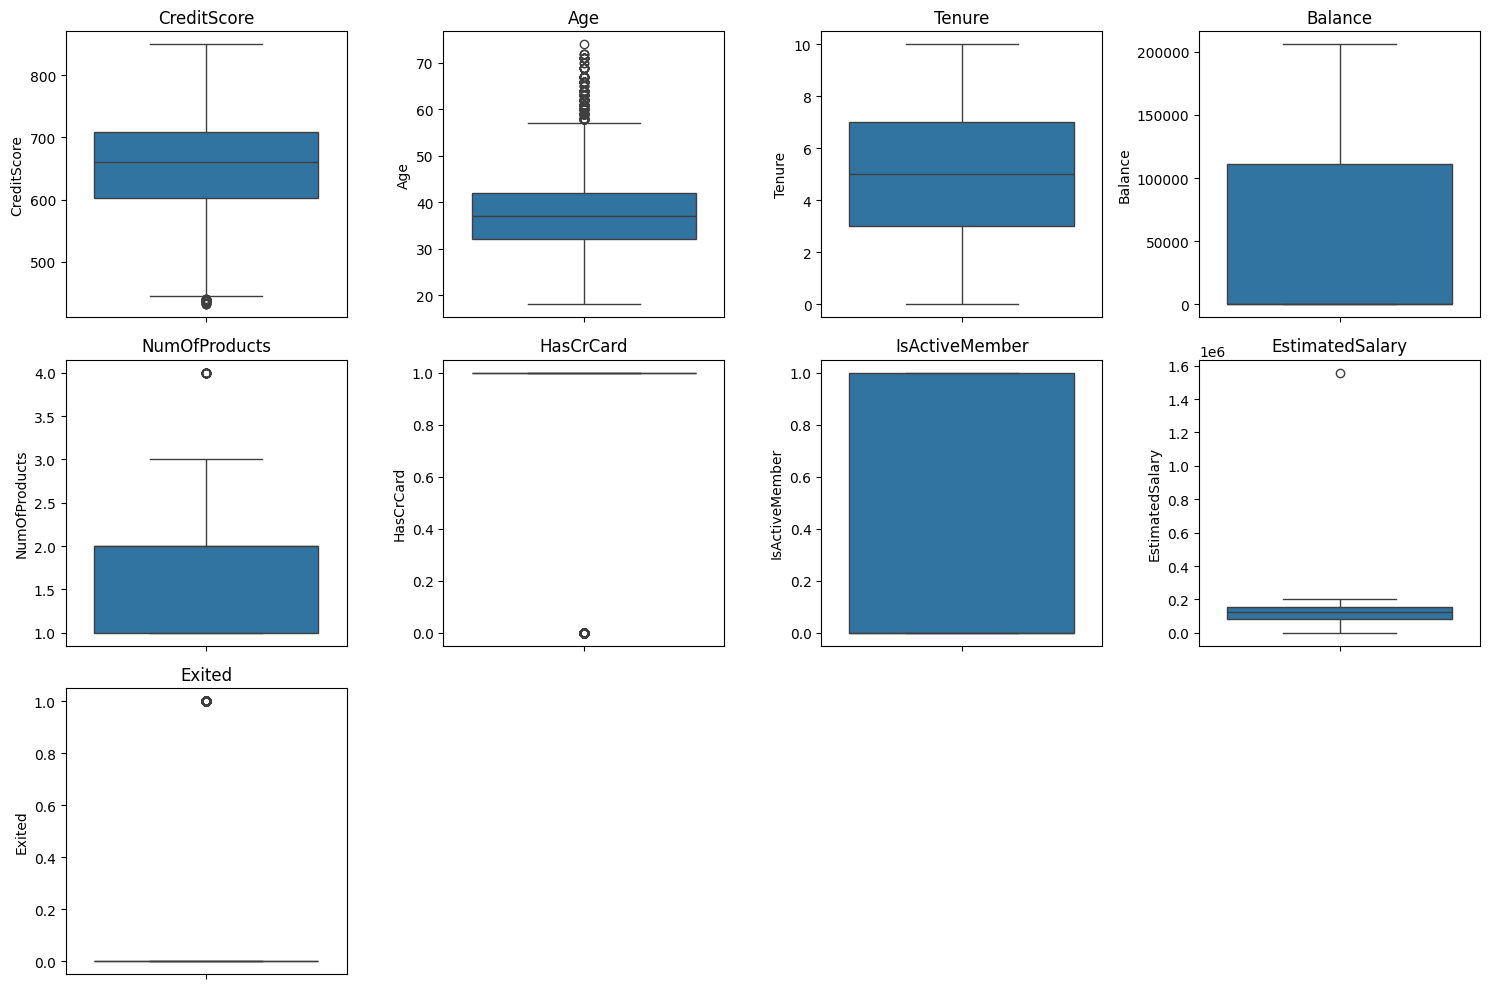

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Correlation Matrix and Heatmap

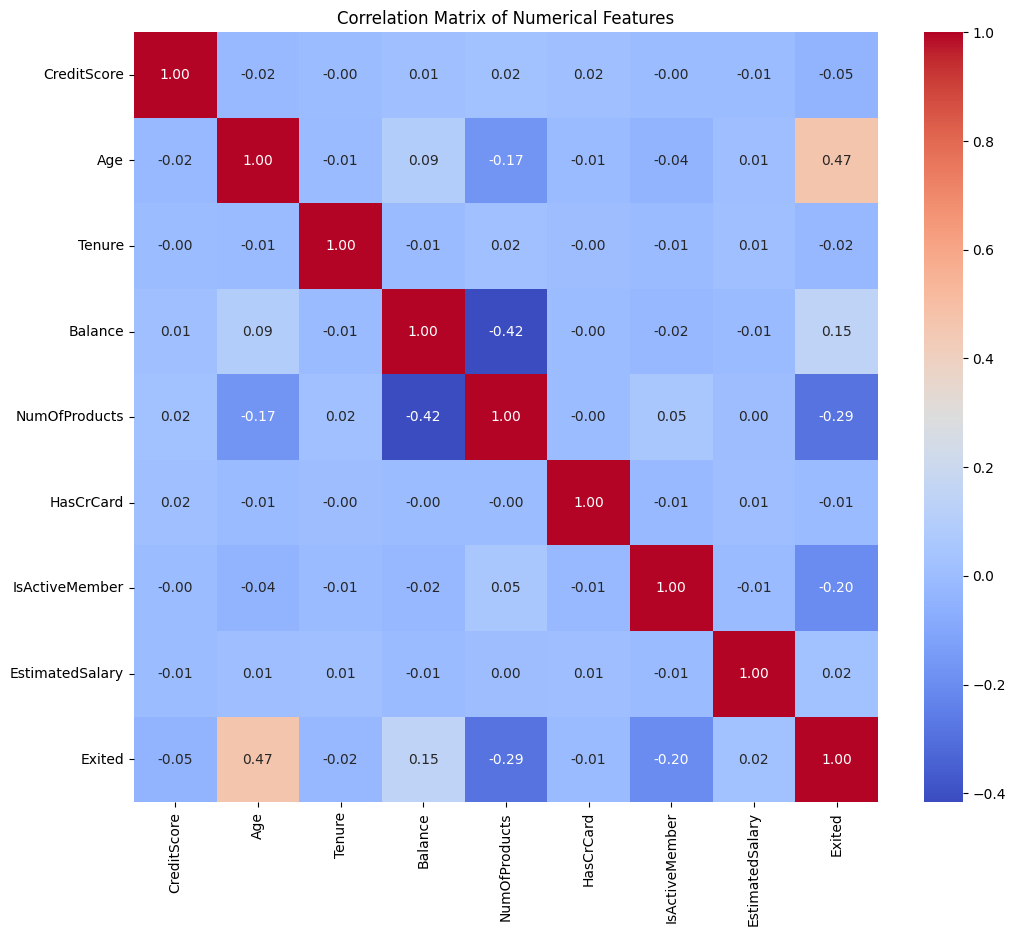

In [13]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Checking Target Variable (Exited) Balance

In [20]:
# Check the distribution of the target variable 'Exited'
print("Value counts for 'Exited' column:")
display(df['Exited'].value_counts())

print("\nPercentage distribution for 'Exited' column:")
display(df['Exited'].value_counts(normalize=True) * 100)

Value counts for 'Exited' column:


,count
Exited,
0.0,11998
1.0,3002



Percentage distribution for 'Exited' column:


,proportion
Exited,
0.0,79.986667
1.0,20.013333


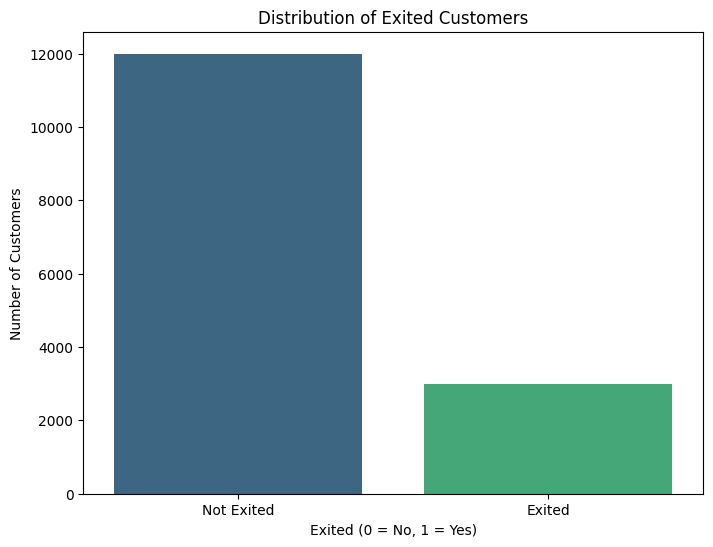

In [22]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Exited', data=df, hue='Exited', palette='viridis', legend=False)
plt.title('Distribution of Exited Customers')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['Not Exited', 'Exited'])
plt.show()

### Splitting Data into Training and Testing Sets with Stratified Sampling

In [24]:
from sklearn.model_selection import train_test_split

# Define features (X) as the preprocessed DataFrame and target (y)
X = X_preprocessed

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (12000, 13)
X_test shape: (3000, 13)
y_train shape: (12000,)
y_test shape: (3000,)


### XGBoost Model

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline with StandardScaler and XGBClassifier
xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb_classifier', XGBClassifier(random_state=42, eval_metric='logloss')) # Removed use_label_encoder
])

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [26]:
# Make predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Make probability predictions for ROC curve
y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Training Set Evaluation (XGBoost) ---")
print(classification_report(y_train, y_train_pred_xgb))

print("\n--- Test Set Evaluation (XGBoost) ---")
print(classification_report(y_test, y_test_pred_xgb))


--- Training Set Evaluation (XGBoost) ---
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      9598
         1.0       0.96      0.87      0.91      2402

    accuracy                           0.97     12000
   macro avg       0.96      0.93      0.95     12000
weighted avg       0.97      0.97      0.97     12000


--- Test Set Evaluation (XGBoost) ---
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2400
         1.0       0.80      0.66      0.72       600

    accuracy                           0.90      3000
   macro avg       0.86      0.81      0.83      3000
weighted avg       0.90      0.90      0.90      3000



ROC AUC on Training Set (XGBoost): 0.9919
ROC AUC on Test Set (XGBoost): 0.9287


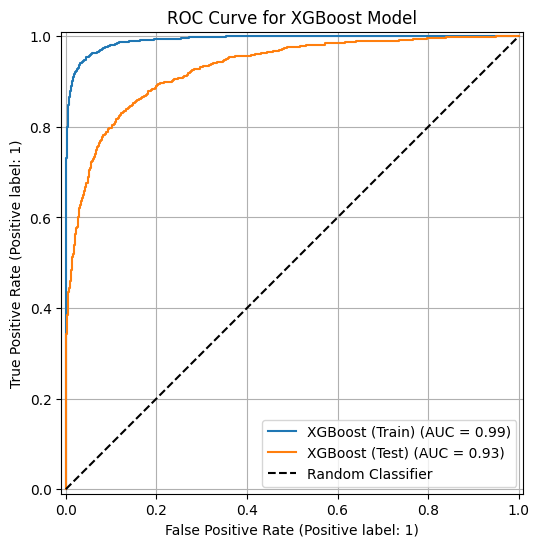

In [27]:
import matplotlib.pyplot as plt

# Calculate ROC AUC scores
roc_auc_train_xgb = roc_auc_score(y_train, y_train_proba_xgb)
roc_auc_test_xgb = roc_auc_score(y_test, y_test_proba_xgb)

print(f"ROC AUC on Training Set (XGBoost): {roc_auc_train_xgb:.4f}")
print(f"ROC AUC on Test Set (XGBoost): {roc_auc_test_xgb:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 6))
ax = plt.gca()

RocCurveDisplay.from_predictions(y_train, y_train_proba_xgb, name='XGBoost (Train)', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_test_proba_xgb, name='XGBoost (Test)', ax=ax)

plt.title('ROC Curve for XGBoost Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.show()

### LightGBM Model

In [33]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline with StandardScaler and LGBMClassifier
lgbm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm_classifier', LGBMClassifier(random_state=42))
])

# Train the LGBM model
lgbm_model.fit(X_train, y_train)

print("LightGBM model trained successfully.")

[LightGBM] [Info] Number of positive: 2402, number of negative: 9598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004877 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 851
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200167 -> initscore=-1.385253
[LightGBM] [Info] Start training from score -1.385253
LightGBM model trained successfully.


In [34]:
# Make predictions
y_train_pred_lgbm = lgbm_model.predict(X_train)
y_test_pred_lgbm = lgbm_model.predict(X_test)

# Make probability predictions for ROC curve
y_train_proba_lgbm = lgbm_model.predict_proba(X_train)[:, 1]
y_test_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Training Set Evaluation (LightGBM) ---")
print(classification_report(y_train, y_train_pred_lgbm))

print("\n--- Test Set Evaluation (LightGBM) ---")
print(classification_report(y_test, y_test_pred_lgbm))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Training Set Evaluation (LightGBM) ---
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      9598
         1.0       0.90      0.78      0.83      2402

    accuracy                           0.94     12000
   macro avg       0.92      0.88      0.90     12000
weighted avg       0.94      0.94      0.94     12000


--- Test Set Evaluation (LightGBM) ---
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2400
         1.0       0.81      0.68      0.74       600

    accuracy                           0.90      3000
   macro avg       0.87      0.82      0.84      3000
weighted avg       0.90      0.90      0.90      3000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC AUC on Training Set (LightGBM): 0.9765
ROC AUC on Test Set (LightGBM): 0.9353


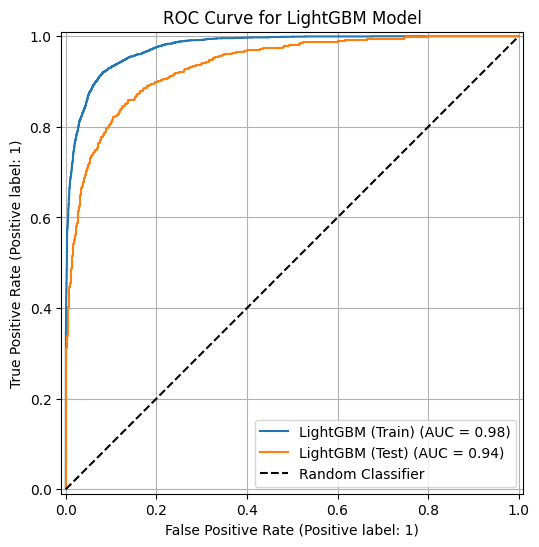

In [35]:
import matplotlib.pyplot as plt

# Calculate ROC AUC scores
roc_auc_train_lgbm = roc_auc_score(y_train, y_train_proba_lgbm)
roc_auc_test_lgbm = roc_auc_score(y_test, y_test_proba_lgbm)

print(f"ROC AUC on Training Set (LightGBM): {roc_auc_train_lgbm:.4f}")
print(f"ROC AUC on Test Set (LightGBM): {roc_auc_test_lgbm:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 6))
ax = plt.gca()

RocCurveDisplay.from_predictions(y_train, y_train_proba_lgbm, name='LightGBM (Train)', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_test_proba_lgbm, name='LightGBM (Test)', ax=ax)

plt.title('ROC Curve for LightGBM Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.show()

### Random Forest Model

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline with StandardScaler and RandomForestClassifier
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [37]:
# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Make probability predictions for ROC curve
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Training Set Evaluation (Random Forest) ---")
print(classification_report(y_train, y_train_pred_rf))

print("\n--- Test Set Evaluation (Random Forest) ---")
print(classification_report(y_test, y_test_pred_rf))


--- Training Set Evaluation (Random Forest) ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9598
         1.0       1.00      1.00      1.00      2402

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000


--- Test Set Evaluation (Random Forest) ---
              precision    recall  f1-score   support

         0.0       0.91      0.96      0.94      2400
         1.0       0.82      0.64      0.71       600

    accuracy                           0.90      3000
   macro avg       0.87      0.80      0.83      3000
weighted avg       0.89      0.90      0.89      3000



ROC AUC on Training Set (Random Forest): 1.0000
ROC AUC on Test Set (Random Forest): 0.9303


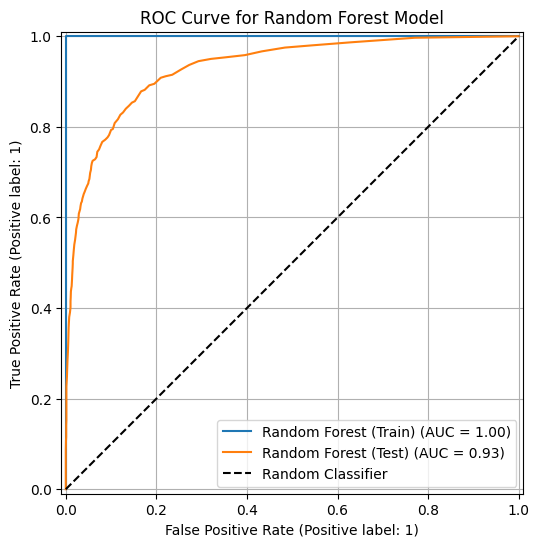

In [38]:
import matplotlib.pyplot as plt

# Calculate ROC AUC scores
roc_auc_train_rf = roc_auc_score(y_train, y_train_proba_rf)
roc_auc_test_rf = roc_auc_score(y_test, y_test_proba_rf)

print(f"ROC AUC on Training Set (Random Forest): {roc_auc_train_rf:.4f}")
print(f"ROC AUC on Test Set (Random Forest): {roc_auc_test_rf:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 6))
ax = plt.gca()

RocCurveDisplay.from_predictions(y_train, y_train_proba_rf, name='Random Forest (Train)', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_test_proba_rf, name='Random Forest (Test)', ax=ax)

plt.title('ROC Curve for Random Forest Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.show()

### Hyperparameter Tuning for Random Forest (max_depth) using GridSearchCV

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define the pipeline for Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Define the parameter grid for max_depth
param_grid = {
    'rf_classifier__max_depth': range(2, 31) # From 2 to 30
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_pipeline,
                              param_grid=param_grid,
                              cv=5, # 5-fold cross-validation
                              scoring='roc_auc', # Use ROC AUC for evaluation
                              n_jobs=-1, # Use all available cores
                              verbose=1)

# Fit GridSearchCV on the training data
grid_search_rf.fit(X_train, y_train)

# Print the best max_depth
print(f"Best max_depth for Random Forest: {grid_search_rf.best_params_['rf_classifier__max_depth']}")

Fitting 5 folds for each of 29 candidates, totalling 145 fits
Best max_depth for Random Forest: 9


Best ROC AUC score for Random Forest with best max_depth: 0.9295

--- Test Set Evaluation (Best Random Forest Model) ---
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94      2400
         1.0       0.85      0.62      0.71       600

    accuracy                           0.90      3000
   macro avg       0.88      0.79      0.83      3000
weighted avg       0.90      0.90      0.90      3000

ROC AUC on Test Set (Best Random Forest): 0.9390


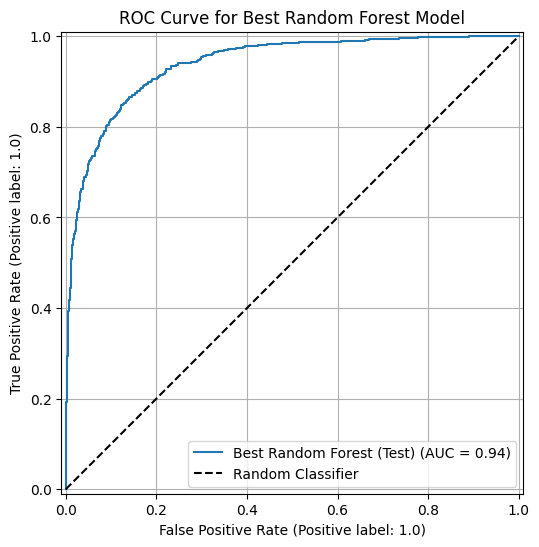

In [40]:
# You can also access the best estimator and its score
print(f"Best ROC AUC score for Random Forest with best max_depth: {grid_search_rf.best_score_:.4f}")

# Optional: Evaluate the best estimator on the test set
best_rf_model = grid_search_rf.best_estimator_
y_test_pred_best_rf = best_rf_model.predict(X_test)
y_test_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Evaluation (Best Random Forest Model) ---")
print(classification_report(y_test, y_test_pred_best_rf))

roc_auc_test_best_rf = roc_auc_score(y_test, y_test_proba_best_rf)
print(f"ROC AUC on Test Set (Best Random Forest): {roc_auc_test_best_rf:.4f}")

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 6))
ax = plt.gca()
RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test, name='Best Random Forest (Test)', ax=ax)
plt.title('ROC Curve for Best Random Forest Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.show()

### Model Comparison and Visualization

In [43]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Create a pipeline with StandardScaler and GaussianNB
# X_train and X_test are already preprocessed (one-hot encoded),
# so the Naive Bayes pipeline should not include OneHotEncoder.
nb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# Train the Naive Bayes model
nb_model.fit(X_train, y_train)

# Make probability predictions for ROC curve
y_test_proba_nb = nb_model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC score for Naive Bayes (Test Set)
roc_auc_test_nb = roc_auc_score(y_test, y_test_proba_nb)

print(f"Naive Bayes model trained successfully. Test ROC AUC: {roc_auc_test_nb:.4f}")

Naive Bayes model trained successfully. Test ROC AUC: 0.8690



--- Model Performance Comparison (Test ROC AUC) ---


,Model,Test ROC AUC
0,Random Forest (Tuned),0.939001
1,LightGBM,0.935314
2,XGBoost (No SMOTE),0.928708
3,XGBoost (with SMOTE),0.923428
4,XGBoost (with PCA),0.923022
5,Naive Bayes,0.868972


/tmp/ipykernel_1319/1817901764.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test ROC AUC', y='Model', data=model_comparison, palette='viridis')


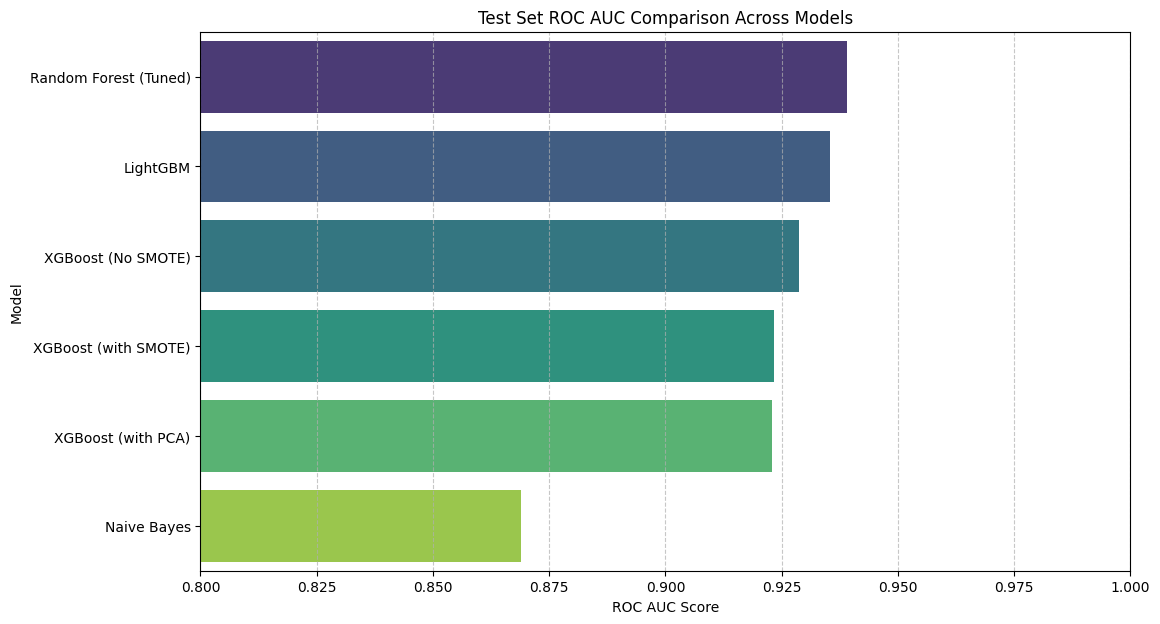

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay

# Collect ROC AUC scores for comparison
model_comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'XGBoost (No SMOTE)',
        'XGBoost (with SMOTE)',
        'LightGBM',
        'Random Forest (Tuned)',
        'XGBoost (with PCA)' # Added XGBoost with PCA
    ],
    'Test ROC AUC': [
        roc_auc_test_nb,
        roc_auc_test_xgb,
        roc_auc_test_xgb_smote,
        roc_auc_test_lgbm,
        roc_auc_test_best_rf,
        roc_auc_test_xgb_pca # Added ROC AUC for XGBoost with PCA
    ]
})

model_comparison = model_comparison.sort_values(by='Test ROC AUC', ascending=False).reset_index(drop=True)

print("\n--- Model Performance Comparison (Test ROC AUC) ---")
display(model_comparison)

# Visualize ROC AUC scores
plt.figure(figsize=(12, 7))
sns.barplot(x='Test ROC AUC', y='Model', data=model_comparison, palette='viridis')
plt.title('Test Set ROC AUC Comparison Across Models')
plt.xlabel('ROC AUC Score')
plt.ylabel('Model')
plt.xlim(0.8, 1.0) # Set x-axis limit for better comparison
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


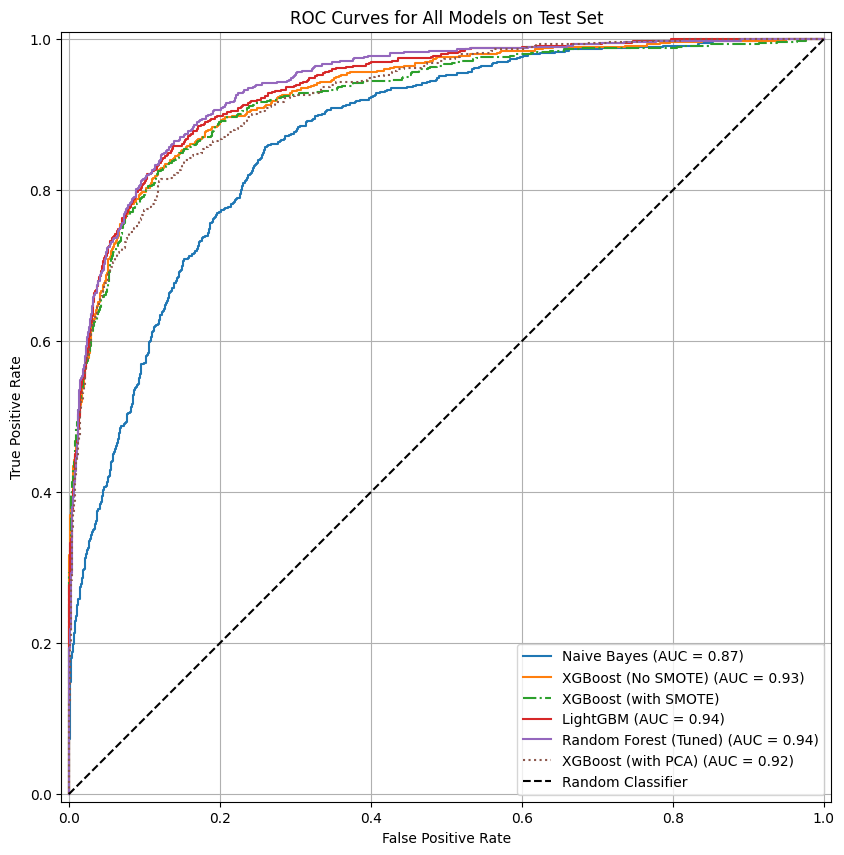

In [60]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Plot all ROC curves on a single graph
plt.figure(figsize=(12, 10))
ax = plt.gca()

# Naive Bayes (using from_predictions to bypass the previous ColumnTransformer error)
RocCurveDisplay.from_predictions(y_test, y_test_proba_nb, name='Naive Bayes', ax=ax)

# XGBoost (No SMOTE)
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name='XGBoost (No SMOTE)', ax=ax)

# XGBoost (with SMOTE - use stored probabilities)
plt.plot(roc_curve(y_test, y_test_proba_xgb_smote)[0], roc_curve(y_test, y_test_proba_xgb_smote)[1], label='XGBoost (with SMOTE)', linestyle='-.') # Changed line style for clarity

# LightGBM
RocCurveDisplay.from_estimator(lgbm_model, X_test, y_test, name='LightGBM', ax=ax)

# Random Forest (Tuned Best Model)
RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test, name='Random Forest (Tuned)', ax=ax)

# XGBoost (with PCA)
RocCurveDisplay.from_predictions(y_test_pca, y_test_proba_xgb_pca, name='XGBoost (with PCA)', ax=ax, linestyle=':') # Added XGBoost with PCA ROC curve

plt.title('ROC Curves for All Models on Test Set')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

## Making Predictions on `test.csv` with the Best Model

In [46]:
test_df = pd.read_csv('test.csv')

print("Original test_df head:")
display(test_df.head())
print(f"Original test_df shape: {test_df.shape}")

Original test_df head:


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15632848.0,Teng,537.0,Spain,Male,27.0,8.0,119027.28,1.0,1.0,0.0,129964.14
1,15001,15797733.0,Onwuamaeze,646.0,France,Male,41.0,6.0,0.00,2.0,1.0,0.0,158523.02
2,15002,15662085.0,Eluemuno,683.0,France,Female,37.0,9.0,0.00,2.0,1.0,0.0,120892.96
3,15003,15744109.0,Hsing,717.0,France,Male,21.0,5.0,0.00,2.0,1.0,1.0,169781.45
4,15004,15635598.0,Calabrese,662.0,Germany,Male,45.0,4.0,121152.05,1.0,1.0,0.0,116286.25


Original test_df shape: (10000, 13)


### Preprocessing `test.csv`

In [47]:
# Drop the same irrelevant columns as in the training data
test_df_processed = test_df.drop(columns=['id', 'CustomerId', 'Surname'])

# Separate features for preprocessing
X_test_submission = test_df_processed.copy()

# Identify categorical features in X_test_submission
categorical_features_test = X_test_submission.select_dtypes(include=['object']).columns.tolist()

# Apply one-hot encoding using the already fitted 'ohe' encoder
# Ensure the columns generated match those from the training set
X_test_encoded_array = ohe.transform(X_test_submission[categorical_features_test])
X_test_encoded_df = pd.DataFrame(X_test_encoded_array, columns=ohe.get_feature_names_out(categorical_features_test), index=X_test_submission.index)

# Drop original categorical columns from X_test_submission and concatenate with encoded ones
X_test_submission_preprocessed = pd.concat([X_test_submission.drop(columns=categorical_features_test), X_test_encoded_df], axis=1)

# Align columns with the training data (X_preprocessed) to ensure consistency
# This is crucial if the test set has different columns or order than the training set
missing_cols_in_test = set(X_preprocessed.columns) - set(X_test_submission_preprocessed.columns)
for c in missing_cols_in_test:
    X_test_submission_preprocessed[c] = 0
# Ensure the order of columns is the same as in X_preprocessed
X_test_submission_preprocessed = X_test_submission_preprocessed[X_preprocessed.columns]

print("Preprocessed test data head:")
display(X_test_submission_preprocessed.head())
print(f"Preprocessed test data shape: {X_test_submission_preprocessed.shape}")

Preprocessed test data head:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,537.0,27.0,8.0,119027.28,1.0,1.0,0.0,129964.14,0.0,0.0,1.0,0.0,1.0
1,646.0,41.0,6.0,0.00,2.0,1.0,0.0,158523.02,1.0,0.0,0.0,0.0,1.0
2,683.0,37.0,9.0,0.00,2.0,1.0,0.0,120892.96,1.0,0.0,0.0,1.0,0.0
3,717.0,21.0,5.0,0.00,2.0,1.0,1.0,169781.45,1.0,0.0,0.0,0.0,1.0
4,662.0,45.0,4.0,121152.05,1.0,1.0,0.0,116286.25,0.0,1.0,0.0,0.0,1.0


Preprocessed test data shape: (10000, 13)


### Generating Predictions

In [48]:
# Predict churn (0 or 1) using the best Random Forest model
test_predictions = best_rf_model.predict(X_test_submission_preprocessed)

# Predict probabilities of churn (for submission format, usually for class 1)
test_probabilities = best_rf_model.predict_proba(X_test_submission_preprocessed)[:, 1]

print("First 10 predictions (0=No Churn, 1=Churn):")
print(test_predictions[:10])

print("\nFirst 10 churn probabilities:")
print(test_probabilities[:10])

First 10 predictions (0=No Churn, 1=Churn):
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

First 10 churn probabilities:
[0.14879999 0.04659673 0.04635882 0.01005312 0.69144761 0.06886138
 0.02510405 0.22549863 0.02499726 0.43734145]


### Prepare Submission File

In [49]:
# Create a submission DataFrame
submission_df = pd.DataFrame({'id': test_df['id'], 'Exited': test_probabilities})

print("Submission file head:")
display(submission_df.head())

# Save the submission file to a CSV
submission_df.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully.")

Submission file head:


,id,Exited
0,15000,0.148800
1,15001,0.046597
2,15002,0.046359
3,15003,0.010053
4,15004,0.691448


Submission file 'submission.csv' created successfully.


## Making Predictions on `test.csv` with the XGBoost Model

In [50]:
# Predict churn (0 or 1) using the XGBoost model
xgb_test_predictions = xgb_model.predict(X_test_submission_preprocessed)

# Predict probabilities of churn (for submission format, usually for class 1)
xgb_test_probabilities = xgb_model.predict_proba(X_test_submission_preprocessed)[:, 1]

print("First 10 predictions (0=No Churn, 1=Churn) from XGBoost:")
print(xgb_test_predictions[:10])

print("\nFirst 10 churn probabilities from XGBoost:")
print(xgb_test_probabilities[:10])

First 10 predictions (0=No Churn, 1=Churn) from XGBoost:
[0 0 0 0 1 0 0 0 0 1]

First 10 churn probabilities from XGBoost:
[2.11312920e-02 9.90863983e-03 3.92148755e-02 1.18635275e-04
 9.07443643e-01 3.85003239e-02 1.69644784e-02 8.91284570e-02
 3.89335211e-03 7.77467012e-01]


### Prepare Submission File for XGBoost

In [51]:
# Create a submission DataFrame for XGBoost
xgb_submission_df = pd.DataFrame({'id': test_df['id'], 'Exited': xgb_test_probabilities})

print("XGBoost Submission file head:")
display(xgb_submission_df.head())

# Save the XGBoost submission file to a CSV
xgb_submission_df.to_csv('submission_xgb.csv', index=False)
print("XGBoost submission file 'submission_xgb.csv' created successfully.")

XGBoost Submission file head:


,id,Exited
0,15000,0.021131
1,15001,0.009909
2,15002,0.039215
3,15003,0.000119
4,15004,0.907444


XGBoost submission file 'submission_xgb.csv' created successfully.


## Principal Component Analysis (PCA)

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Scale the preprocessed data before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_preprocessed)

# Convert to DataFrame for easier inspection (optional, but good for understanding)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_preprocessed.columns)

print("Scaled data head:")
display(X_scaled_df.head())

Scaled data head:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-1.415061,-0.703670,-0.743596,0.930829,-1.112662,-1.874203,1.030739,1.260272,0.817631,-0.464283,-0.53624,1.139980,-1.139980
1,0.707510,0.032207,1.403871,-0.716825,0.773419,-1.874203,-0.970178,0.512791,0.817631,-0.464283,-0.53624,-0.877208,0.877208
2,-0.748356,0.032207,1.403871,1.565056,-1.112662,0.533560,1.030739,-0.583353,0.817631,-0.464283,-0.53624,1.139980,-1.139980
3,0.707510,-0.335732,1.045959,-0.716825,0.773419,0.533560,-0.970178,0.660043,0.817631,-0.464283,-0.53624,1.139980,-1.139980
4,0.272111,-0.458378,1.045959,-0.716825,0.773419,-1.874203,-0.970178,0.654026,0.817631,-0.464283,-0.53624,-0.877208,0.877208


### Applying PCA and Visualizing Explained Variance

Explained variance ratio per principal component:
PC1: 0.1722
PC2: 0.1521
PC3: 0.1202
PC4: 0.0807
PC5: 0.0788
PC6: 0.0780
PC7: 0.0760
PC8: 0.0754
PC9: 0.0736
PC10: 0.0669
PC11: 0.0263
PC12: 0.0000
PC13: 0.0000

Cumulative explained variance:
Up to PC1: 0.1722
Up to PC2: 0.3242
Up to PC3: 0.4444
Up to PC4: 0.5251
Up to PC5: 0.6039
Up to PC6: 0.6819
Up to PC7: 0.7579
Up to PC8: 0.8332
Up to PC9: 0.9069
Up to PC10: 0.9737
Up to PC11: 1.0000
Up to PC12: 1.0000
Up to PC13: 1.0000


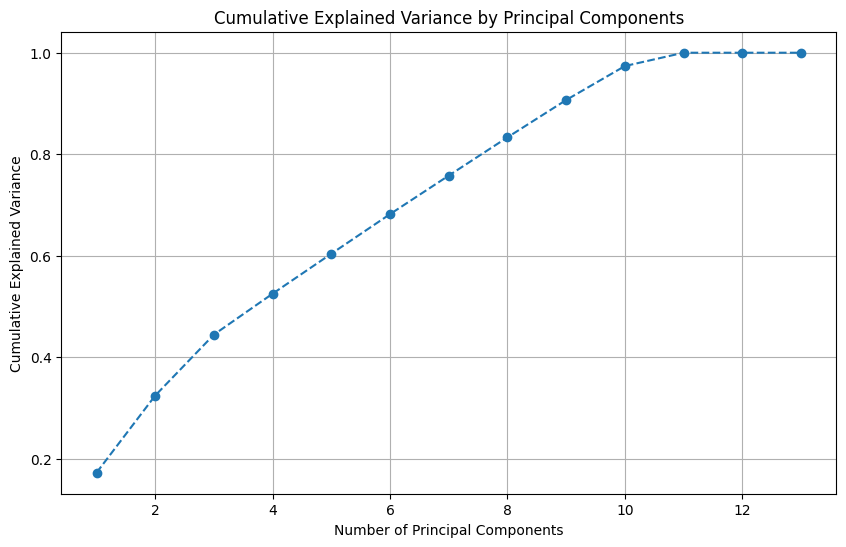


First 5 rows of Principal Components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,0.598308,1.522590,-1.097251,0.397589,-1.800694,1.701785,1.230773,0.818293,-0.281821,-1.551877,0.489918,1.076295e-15,-4.181675e-16
1,-1.678691,-0.540766,-0.530116,0.275357,0.548063,1.275190,-1.703839,1.542926,-0.436081,0.379150,-0.023804,-7.079542e-16,-1.475091e-15
2,1.010548,1.329545,-1.269302,-0.138919,-0.203934,0.750629,-0.373087,-1.493383,1.402918,-1.127759,1.021635,-1.449503e-16,-1.961229e-16
3,-0.623816,2.017715,-0.267969,-0.439632,1.766062,0.238031,-0.457469,0.207481,-0.280687,0.136391,0.030225,-1.449503e-16,-6.402121e-16
4,-1.761714,-0.541245,-0.484060,0.209123,0.331485,1.383038,-1.285075,1.382089,-0.902088,0.083951,-0.052428,-5.969319e-16,-1.364069e-15


In [53]:
# Initialize PCA - keeping all components initially to decide later
pca = PCA(n_components=None)
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio per principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative explained variance:")
for i, cum_ratio in enumerate(cumulative_explained_variance):
    print(f"Up to PC{i+1}: {cum_ratio:.4f}")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Transform the scaled data to principal components
X_pca = pca.transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

print("\nFirst 5 rows of Principal Components:")
display(X_pca_df.head())

## XGBoost Model with PCA Features

In [54]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Split X_pca into training and testing sets.
# Ensure the split is consistent with the original split of X_preprocessed and y.
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

X_train_pca shape: (12000, 13)
X_test_pca shape: (3000, 13)


In [55]:
# Initialize and train a new XGBoost Classifier directly on PCA components
# Since PCA components are already scaled, a separate StandardScaler is not strictly needed within this pipeline if X_pca was already scaled.
xgb_model_pca = XGBClassifier(random_state=42, eval_metric='logloss')

# Train the XGBoost model on PCA-transformed training data
xgb_model_pca.fit(X_train_pca, y_train_pca)

print("XGBoost model trained successfully on PCA features.")

XGBoost model trained successfully on PCA features.



--- Training Set Evaluation (XGBoost with PCA) ---
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      9598
         1.0       0.97      0.92      0.94      2402

    accuracy                           0.98     12000
   macro avg       0.98      0.96      0.97     12000
weighted avg       0.98      0.98      0.98     12000


--- Test Set Evaluation (XGBoost with PCA) ---
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2400
         1.0       0.79      0.66      0.72       600

    accuracy                           0.90      3000
   macro avg       0.86      0.81      0.83      3000
weighted avg       0.89      0.90      0.89      3000


ROC AUC on Training Set (XGBoost with PCA): 0.9975
ROC AUC on Test Set (XGBoost with PCA): 0.9230


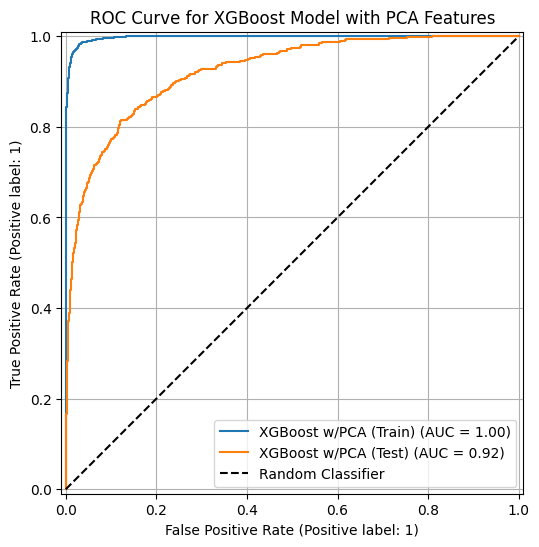

In [56]:
# Make predictions
y_train_pred_xgb_pca = xgb_model_pca.predict(X_train_pca)
y_test_pred_xgb_pca = xgb_model_pca.predict(X_test_pca)

# Make probability predictions for ROC curve
y_train_proba_xgb_pca = xgb_model_pca.predict_proba(X_train_pca)[:, 1]
y_test_proba_xgb_pca = xgb_model_pca.predict_proba(X_test_pca)[:, 1]

# Evaluate the model
print("\n--- Training Set Evaluation (XGBoost with PCA) ---")
print(classification_report(y_train_pca, y_train_pred_xgb_pca))

print("\n--- Test Set Evaluation (XGBoost with PCA) ---")
print(classification_report(y_test_pca, y_test_pred_xgb_pca))

# Calculate ROC AUC scores
roc_auc_train_xgb_pca = roc_auc_score(y_train_pca, y_train_proba_xgb_pca)
roc_auc_test_xgb_pca = roc_auc_score(y_test_pca, y_test_proba_xgb_pca)

print(f"\nROC AUC on Training Set (XGBoost with PCA): {roc_auc_train_xgb_pca:.4f}")
print(f"ROC AUC on Test Set (XGBoost with PCA): {roc_auc_test_xgb_pca:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 6))
ax = plt.gca()

RocCurveDisplay.from_predictions(y_train_pca, y_train_proba_xgb_pca, name='XGBoost w/PCA (Train)', ax=ax)
RocCurveDisplay.from_predictions(y_test_pca, y_test_proba_xgb_pca, name='XGBoost w/PCA (Test)', ax=ax)

plt.title('ROC Curve for XGBoost Model with PCA Features')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.show()

### Generating Predictions on `test.csv` with XGBoost (PCA-based)

In [57]:
# Apply the same scaling and PCA transformation to the test submission data
X_test_submission_scaled = scaler.transform(X_test_submission_preprocessed)
X_test_submission_pca = pca.transform(X_test_submission_scaled)

# Predict churn probabilities using the PCA-trained XGBoost model
xgb_pca_test_probabilities = xgb_model_pca.predict_proba(X_test_submission_pca)[:, 1]

print("First 10 churn probabilities from XGBoost with PCA:")
print(xgb_pca_test_probabilities[:10])

First 10 churn probabilities from XGBoost with PCA:
[5.4677865e-03 3.6391821e-03 7.9184994e-03 3.1941669e-04 6.7459309e-01
 7.2728032e-03 7.5566694e-03 5.9118360e-02 1.3309143e-03 5.1503503e-01]


### Prepare Submission File for XGBoost (PCA-based)

In [58]:
# Create a submission DataFrame for XGBoost with PCA
xgb_pca_submission_df = pd.DataFrame({'id': test_df['id'], 'Exited': xgb_pca_test_probabilities})

print("XGBoost (PCA) Submission file head:")
display(xgb_pca_submission_df.head())

# Save the XGBoost (PCA) submission file to a CSV
xgb_pca_submission_df.to_csv('submission_xgb_pca.csv', index=False)
print("XGBoost (PCA) submission file 'submission_xgb_pca.csv' created successfully.")

XGBoost (PCA) Submission file head:


,id,Exited
0,15000,0.005468
1,15001,0.003639
2,15002,0.007918
3,15003,0.000319
4,15004,0.674593


XGBoost (PCA) submission file 'submission_xgb_pca.csv' created successfully.


## Cross-Validation for Robust Model Evaluation

To get a more reliable estimate of our models' performance and to ensure they generalize well to unseen data, we will implement **Stratified K-Fold Cross-Validation**. This approach involves:

1.  **Splitting the data:** Dividing the training data into 'k' folds.
2.  **Iterative Training and Validation:** For each iteration, one fold is used as the validation set, and the remaining k-1 folds are used for training.
3.  **Stratification:** Ensuring that each fold has approximately the same percentage of samples of each target class as the complete set, which is crucial for our imbalanced 'Exited' target variable.
4.  **Aggregating Results:** Calculating performance metrics (e.g., ROC AUC, Precision, Recall, F1-Score) for each fold and then averaging them to get an overall performance estimate.

In [61]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define the number of splits for K-Fold cross-validation
N_SPLITS = 5 # A common choice

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"Initialized StratifiedKFold with {N_SPLITS} splits.")

Initialized StratifiedKFold with 5 splits.


### Cross-Validation Function

To ensure consistency and ease of use, I'll define a function `run_cross_validation` that takes a model pipeline, the full dataset (`X`, `y`), and the `StratifiedKFold` object. This function will:

-   Iterate through each fold provided by `StratifiedKFold`.
-   Train the model on the training folds and evaluate it on the validation fold.
-   Collect ROC AUC, Precision, Recall, and F1-score for each fold.
-   Return the average (mean) of these metrics across all folds, along with the standard deviation to indicate variability.

In [62]:
def run_cross_validation(model_pipeline, X, y, skf):
    roc_auc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    accuracy_scores = []

    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

        # Fit the model pipeline
        model_pipeline.fit(X_train_fold, y_train_fold)

        # Make predictions and probabilities on the validation set
        y_pred_fold = model_pipeline.predict(X_val_fold)
        y_proba_fold = model_pipeline.predict_proba(X_val_fold)[:, 1]

        # Calculate metrics
        roc_auc_scores.append(roc_auc_score(y_val_fold, y_proba_fold))
        precision_scores.append(precision_score(y_val_fold, y_pred_fold))
        recall_scores.append(recall_score(y_val_fold, y_pred_fold))
        f1_scores.append(f1_score(y_val_fold, y_pred_fold))
        accuracy_scores.append(model_pipeline.score(X_val_fold, y_val_fold))

    print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} (+/- {np.std(roc_auc_scores):.4f})")
    print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
    print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
    print(f"Average F1-score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
    print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")

    return {
        'roc_auc': np.mean(roc_auc_scores),
        'roc_auc_std': np.std(roc_auc_scores),
        'precision': np.mean(precision_scores),
        'precision_std': np.std(precision_scores),
        'recall': np.mean(recall_scores),
        'recall_std': np.std(recall_scores),
        'f1_score': np.mean(f1_scores),
        'f1_score_std': np.std(f1_scores),
        'accuracy': np.mean(accuracy_scores),
        'accuracy_std': np.std(accuracy_scores)
    }

### Cross-Validation for Naive Bayes Model

In [63]:
print("\n--- Evaluating Naive Bayes Model with Cross-Validation ---")
nb_cv_results = run_cross_validation(nb_model, X_preprocessed, y, skf)
cv_results_df = pd.DataFrame([{'Model': 'Naive Bayes', **nb_cv_results}])


--- Evaluating Naive Bayes Model with Cross-Validation ---
Average ROC AUC: 0.8668 (+/- 0.0083)
Average Precision: 0.5874 (+/- 0.0209)
Average Recall: 0.5946 (+/- 0.0188)
Average F1-score: 0.5907 (+/- 0.0154)
Average Accuracy: 0.8351 (+/- 0.0075)


### Cross-Validation for XGBoost (No SMOTE) Model

In [64]:
print("\n--- Evaluating XGBoost (No SMOTE) Model with Cross-Validation ---")
# For XGBoost, X_preprocessed is the input to the pipeline, as it handles scaling internally.
xgb_cv_results = run_cross_validation(xgb_model, X_preprocessed, y, skf)
cv_results_df = pd.concat([cv_results_df, pd.DataFrame([{'Model': 'XGBoost (No SMOTE)', **xgb_cv_results}])], ignore_index=True)


--- Evaluating XGBoost (No SMOTE) Model with Cross-Validation ---
Average ROC AUC: 0.9248 (+/- 0.0036)
Average Precision: 0.7790 (+/- 0.0099)
Average Recall: 0.6795 (+/- 0.0073)
Average F1-score: 0.7259 (+/- 0.0065)
Average Accuracy: 0.8973 (+/- 0.0026)


### Cross-Validation for XGBoost (with SMOTE) Model

In [65]:
print("\n--- Evaluating XGBoost (with SMOTE) Model with Cross-Validation ---")
# X_train_resampled and y_train_resampled are from the SMOTE section, but run_cross_validation expects X_preprocessed and y.
# For the SMOTE model, we need to adapt its training to be within the cross-validation loop.
# This requires re-creating the SMOTE-pipeline logic inside run_cross_validation or ensuring the model itself has SMOTE integrated.
# Looking at the original definition, xgb_smote_model is likely a pipeline that includes SMOTE.

# Assuming `xgb_smote_model` was defined earlier with a pipeline including SMOTE and an XGBoost classifier.
# However, the run_cross_validation function assumes X and y are the original, unprocessed data.
# The SMOTE logic should be inside the pipeline if we want to run cross-validation correctly.

# If xgb_smote_model is not a pipeline that includes SMOTE as a step, we'll need to define it as such.
# Let's assume for now that `xgb_smote_model` was correctly set up with a pipeline where SMOTE is applied only on training folds.
# If `xgb_smote_model` is just the classifier trained on already SMOTEd data, we'll need to adjust.

# Let's re-define `xgb_smote_model` to explicitly include SMOTE within a pipeline for proper cross-validation.
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

xgb_smote_model_cv = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb_classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_smote_cv_results = run_cross_validation(xgb_smote_model_cv, X_preprocessed, y, skf)
cv_results_df = pd.concat([cv_results_df, pd.DataFrame([{'Model': 'XGBoost (with SMOTE)', **xgb_smote_cv_results}])], ignore_index=True)


--- Evaluating XGBoost (with SMOTE) Model with Cross-Validation ---
Average ROC AUC: 0.9249 (+/- 0.0047)
Average Precision: 0.7323 (+/- 0.0171)
Average Recall: 0.7195 (+/- 0.0162)
Average F1-score: 0.7258 (+/- 0.0154)
Average Accuracy: 0.8912 (+/- 0.0063)


### Cross-Validation for LightGBM Model

In [66]:
print("\n--- Evaluating LightGBM Model with Cross-Validation ---")
# For LightGBM, X_preprocessed is the input to the pipeline, as it handles scaling internally.
lgbm_cv_results = run_cross_validation(lgbm_model, X_preprocessed, y, skf)
cv_results_df = pd.concat([cv_results_df, pd.DataFrame([{'Model': 'LightGBM', **lgbm_cv_results}])], ignore_index=True)


--- Evaluating LightGBM Model with Cross-Validation ---
[LightGBM] [Info] Number of positive: 2402, number of negative: 9598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 855
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200167 -> initscore=-1.385253
[LightGBM] [Info] Start training from score -1.385253


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2402, number of negative: 9598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 854
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200167 -> initscore=-1.385253
[LightGBM] [Info] Start training from score -1.385253


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2402, number of negative: 9598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 853
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200167 -> initscore=-1.385253
[LightGBM] [Info] Start training from score -1.385253


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2401, number of negative: 9599
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 852
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200083 -> initscore=-1.385774
[LightGBM] [Info] Start training from score -1.385774


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2401, number of negative: 9599
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 853
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200083 -> initscore=-1.385774
[LightGBM] [Info] Start training from score -1.385774
Average ROC AUC: 0.9330 (+/- 0.0043)
Average Precision: 0.7986 (+/- 0.0109)
Average Recall: 0.6879 (+/- 0.0133)
Average F1-score: 0.7390 (+/- 0.0097)
Average Accuracy: 0.9028 (+/- 0.0033)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
